# Exercise

 - Import data on emotion
 - Train a CNN to classify by emotion (Angry, Disgust, Fear, Happy...)
 - Use Data augmentaion techinques to improve you accuracy
 - Compare your results with DeepFace Library https://pypi.org/project/deepface/

In [5]:
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 46.4 MB/s eta 0:00:0000:0100:01


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tabulate import tabulate

import cv2 as cv
import pathlib
from PIL import Image

from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
from google.colab import drive
drive.mount('/content/gdrive')

ModuleNotFoundError: No module named 'google.colab'

In [15]:
url = '/Users/javialvarez/Desktop/CNN_emotions/emotions'
data = pathlib.Path(url)
paths = {
    "Angry": list(data.glob('Angry/*.png')),
    "Disgust": list(data.glob('Disgust/*.png')),
    "Fear": list(data.glob('Fear/*.png')),
    "Happy" : list(data.glob('Happy/*.png')),
    "Neutral" : list(data.glob('Neutral/*.png')),
    "Sad" : list(data.glob('Sad/*.png')),
    "Surprise" : list(data.glob('Surprise/*.png'))
}

labels = {
    "Angry" : 0,
    "Disgust":1,
    "Fear":2,
    "Happy":3,
    "Neutral":4,
    "Sad":5,
    "Surprise":6
}

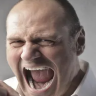

In [17]:
Image.open(str(paths["Angry"][0]))

In [23]:
X=[]
y=[]

for name, images in paths.items():
    for image in images:
        try:
            print(name)
            image = str(image).strip()
            img = cv.imread(image)
            img_resize = cv.resize(img,(200,200))
            X.append(img_resize)
            y.append(labels[name])

        except:
            print('Except')

X = np.array(X)
y = np.array(y)
X.shape

Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Angry
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Disgust
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Fear
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Happy
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral
Neutral


(221, 200, 200, 3)

In [25]:
for label in y:
  print(label)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6


Text(0, 0.5, 'Count')

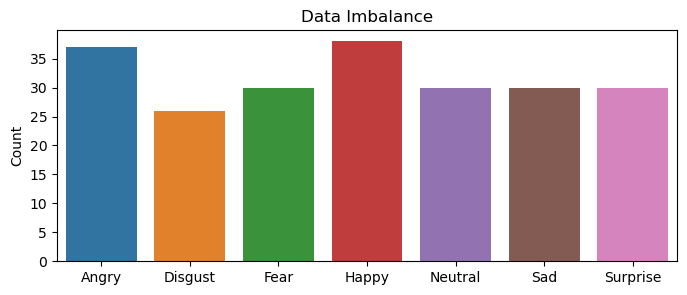

In [27]:
plt.figure(figsize=(8, 3))
g = sns.countplot(x = y)
g.set_xticks(range(len(list(labels.keys()))))
g.set_xticklabels(list(labels.keys()))
plt.title('Data Imbalance')
# plt.xlabel('emotions')
plt.ylabel('Count')

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(176, 200, 200, 3)

## Training CNN

In [35]:
model = Sequential()

model.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(200,200,3)))
model.add(Dropout(0.2))
model.add(MaxPooling2D(pool_size=(2, 2), strides=1, padding="valid"))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Conv2D(264,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))

model.add(Dense(7,activation='softmax'))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size = 100,
                    validation_data=(X_test, y_test))

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.1988 - loss: 517.3431 - val_accuracy: 0.2667 - val_loss: 138.1229
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.1874 - loss: 406.7340 - val_accuracy: 0.1333 - val_loss: 9.0807
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 8s/step - accuracy: 0.1665 - loss: 32.5709 - val_accuracy: 0.1556 - val_loss: 3.6616
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step - accuracy: 0.1514 - loss: 6.8763 - val_accuracy: 0.1333 - val_loss: 2.3468
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 9s/step - accuracy: 0.1997 - loss: 2.7083 - val_accuracy: 0.1556 - val_loss: 1.9835
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step - accuracy: 0.1850 - loss: 1.9609 - val_accuracy: 0.0667 - val_loss: 1.9471
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 8s/step - accuracy: 0.2248 - loss: 1.8907 - val_accuracy: 0.2222 - val_loss: 1.9041
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 9s/step - accuracy: 0.2955 - loss: 1.8212 - val_accuracy: 0.1111 - val_loss: 1.9929
E

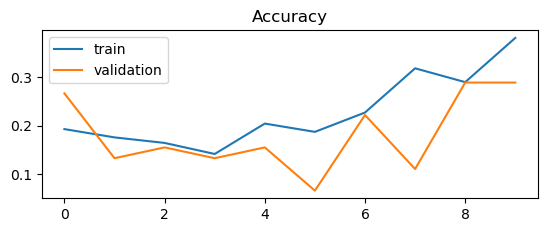

In [37]:
plt.subplot(211)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()

## Data Augmentation

In [63]:
img_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    # rescale=1./255,
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.4,
    # brightness_range = [0.2, 0.5],
    vertical_flip = True,
    horizontal_flip = True,
    zoom_range = 0.2
    )

# img_gen.fit(X_train)
augmented_data_generator  = img_gen.flow(X_train, y_train, batch_size=176) # ,subset='training',shuffle=True
batch = next(augmented_data_generator)

In [65]:
X_train.shape

(176, 200, 200, 3)

In [67]:
X_train_aug = np.concatenate((X_train, batch[0]), axis=0)
y_train_aug = np.concatenate((y_train, batch[1]), axis=0)

In [69]:
labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad",
    6: "Neutral",
    
}


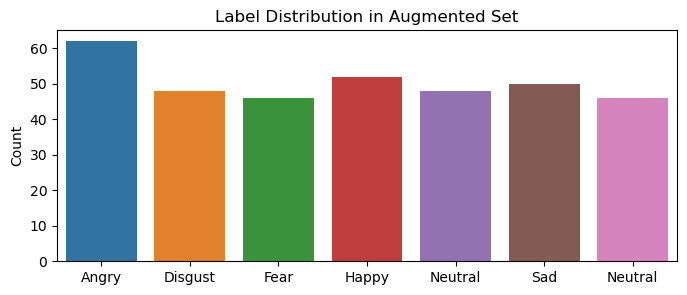

In [71]:
# If you want the combined distribution (original + augmented):
y_plot = y_train_aug

# Or, if you only care about the *newly* augmented batch:
# y_plot = batch[1]

plt.figure(figsize=(8, 3))
g = sns.countplot(x=y_plot)

# Set tick positions and text from your labels dict
g.set_xticks(range(len(labels)))
g.set_xticklabels([labels[i] for i in labels.keys()])

plt.title("Label Distribution in Augmented Set")
plt.ylabel("Count")
plt.xlabel("")     # or put a label like plt.xlabel("Classes")

plt.show()

In [51]:
model = Sequential()

model.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(200,200,3), kernel_regularizer=l1(0.01)))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Conv2D(264,(3,3),padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128,activation='relu', kernel_regularizer=l1(0.01)))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu', kernel_regularizer=l1(0.01)))

model.add(Dense(7,activation='softmax')) # 6 es por el número de clases a clasificar

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train_aug, y_train_aug, epochs=40, batch_size = 50,
                    validation_data=(X_test, y_test))

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1387 - loss: 494.8709 - val_accuracy: 0.1111 - val_loss: 206.3104
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1386 - loss: 197.7509 - val_accuracy: 0.2444 - val_loss: 182.0831
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1452 - loss: 175.8119 - val_accuracy: 0.0444 - val_loss: 156.1311
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1570 - loss: 152.1478 - val_accuracy: 0.1333 - val_loss: 137.9043
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2114 - loss: 134.2254 - val_accuracy: 0.2444 - val_loss: 122.6571
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2247 - loss: 119.3774 - val_accuracy: 0.2222 - val_loss: 109.5694
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2215 - loss: 106.9660 - val_accuracy: 0.1778 - val_loss: 98.8566
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2321 - loss: 96.6272 - val_accuracy: 0.1333 - 

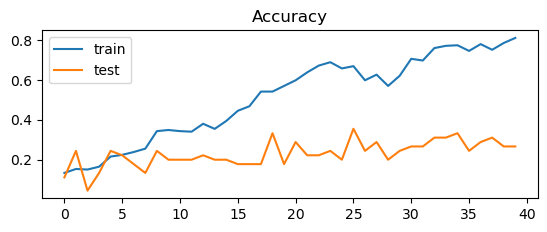

In [73]:
plt.subplot(211)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()

In [75]:
def plot_confusion_matrix(y_test,y_pred,model_name):
    plt.figure(figsize=(5,5))
    #cm = confusion_matrix(y_test,y_pred)
    cm = tf.math.confusion_matrix(y_test,y_pred)
    hmap = sns.heatmap(cm,cbar=False,annot=True,cmap="Blues",fmt='.0f')
    hmap.set_title('Confusion Matrix {}'.format(model_name))
    hmap.set_xlabel('predicted label')
    hmap.set_ylabel('true label')
    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.2299 - loss: 16.6611
Independent Test Accuracy:  0.2666666805744171


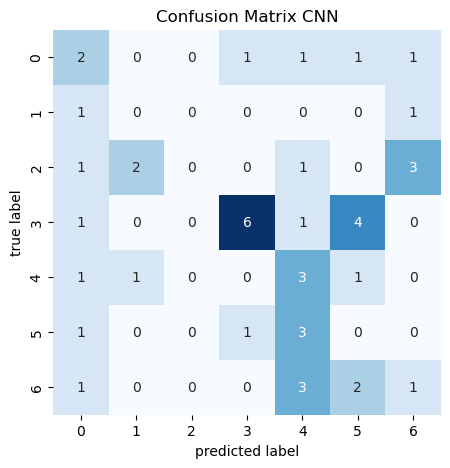

              precision    recall  f1-score   support

           0       0.25      0.33      0.29         6
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         7
           3       0.75      0.50      0.60        12
           4       0.25      0.50      0.33         6
           5       0.00      0.00      0.00         5
           6       0.17      0.14      0.15         7

    accuracy                           0.27        45
   macro avg       0.20      0.21      0.20        45
weighted avg       0.29      0.27      0.27        45



/Users/javialvarez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/javialvarez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/javialvarez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [77]:
y_preds = model.predict(X_test)
print("Independent Test Accuracy: ",model.evaluate(X_test,y_test)[1])
y_preds_tranf = [np.argmax(y_preds[i]) for i in range(len(y_preds))]
plot_confusion_matrix(y_test,y_preds_tranf,'CNN')
print(classification_report(y_test, y_preds_tranf))

## Deepface


In [75]:
# !pip install deepface
from deepface import DeepFace

Directory  /root /.deepface created
Directory  /root /.deepface/weights created


In [80]:
objs = DeepFace.analyze(img_path = '/content/gdrive/MyDrive/Advanced Data Analytics UAX/data/4.-CNN/emotions/Angry/image 72.png',
        actions = ['age', 'gender', 'race', 'emotion'])

Action: emotion: 100%|██████████| 4/4 [00:04<00:00,  1.18s/it]


In [81]:
objs

[{'age': 27,
  'region': {'x': 16, 'y': 19, 'w': 64, 'h': 64},
  'gender': {'Woman': 0.01079259964171797, 'Man': 99.98921155929565},
  'dominant_gender': 'Man',
  'race': {'asian': 7.705220705191722e-05,
   'indian': 0.0026949848263366685,
   'black': 99.99686479531107,
   'white': 7.029602738570613e-08,
   'middle eastern': 3.224475793290273e-08,
   'latino hispanic': 0.000364087075214794},
  'dominant_race': 'black',
  'emotion': {'angry': 70.22527697387659,
   'disgust': 0.021527718874204918,
   'fear': 19.68254979640839,
   'happy': 9.318992116331115,
   'sad': 0.5968885742144077,
   'surprise': 0.11439322460660035,
   'neutral': 0.04037490770499053},
  'dominant_emotion': 'angry'}]